In [1]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# -----------------------------
# Simulation family for parity
# Alexandra's study: M3000, Sigma_cloud = 0.1
# -----------------------------
BASE_LOW_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1'

SIM_PATHS = {
    0.01: os.path.join(BASE_LOW_DENSITY, 'sfeff001_00') + '/',
    0.03: os.path.join(BASE_LOW_DENSITY, 'sfeff003_00') + '/',
    0.10: os.path.join(BASE_LOW_DENSITY, 'sfeff010_00') + '/',
    0.30: os.path.join(BASE_LOW_DENSITY, 'sfeff030_00') + '/',
    1.00: os.path.join(BASE_LOW_DENSITY, 'sfeff100_00') + '/',
}

EFF_VALUES = [0.01, 0.03, 0.10, 0.30, 1.00]

# From the earlier study / your notes for M3000, Sigma=0.1
T_STAR_BY_EFF = {
    0.01: 19.40,
    0.03: 6.47,
    0.10: 1.94,
    0.30: 0.65,
    1.00: 0.19,
}

# -----------------------------
# PARSEC setup
# -----------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

# Switch to PARSEC here
evo_model = evolution.Parsec()   # if this exact class name differs in your install, adjust
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# We only need two dummy filters for the current interpolator interface.
# HR metrics use lum / Teff / logg, not the filter outputs.
filt_list = ['jwst,F115W', 'jwst,F200W']
filters = ['m_jwst_F115W', 'm_jwst_F200W']

iso_dir = 'isochrones/'

# -----------------------------
# Metric definition: parity with Alexandra
# six 100 K bins from 3000 to 3600 K
# -----------------------------
TEMP_BIN_EDGES = np.arange(3000, 3601, 100)   # 3000, 3100, ..., 3600

In [3]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr

In [4]:
def build_isochrone_grid(
    ages_yr,
    increment_yr=0.1e6,
    min_age_floor_yr=10**6.6,   # PARSEC minimum age in SPISEA
):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid

In [5]:
def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filters):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, filters)
    except Exception:
        return None

In [6]:
def interpolate_snapshot_hr(cluster_table, increment_yr=0.1e6):
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)
    level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
        ages_yr,
        increment_yr=increment_yr
    )

    rows = []
    for m, a in zip(masses, ages_myr):
        star = safe_interpolate(a, m, iso_grid, log_age_arr, filters)
        if star is None:
            continue

        # interpolator output:
        # [lum, teff, logg, filt1, filt2]
        lum = float(star[0])
        teff = float(star[1])
        logg = float(star[2])

        if lum <= 0 or teff <= 0:
            continue

        rows.append({
            'mass': m,
            'age_myr': a,
            'lum_watts': lum,
            'lum_lsun': lum / 3.846e26,
            'logL': np.log10(lum / 3.846e26),
            'teff': teff,
            'logTeff': np.log10(teff),
            'logg': logg,
        })

    return pd.DataFrame(rows), iso_grid, level_age_arr_yr

In [7]:
def top_bottom_quartile_gap(values):
    """
    Mean(top 25%) - mean(bottom 25%)
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 4:
        return np.nan

    values = np.sort(values)
    q = max(1, len(values) // 4)

    bottom = values[:q]
    top = values[-q:]

    return np.mean(top) - np.mean(bottom)


def compute_hr_metrics(df_hr, cluster_table, temp_bin_edges=TEMP_BIN_EDGES):
    """
    Returns:
      sigma_L : mean quartile-gap luminosity spread across temperature bins
      mu_L    : mean of mean luminosities across temperature bins
      dt90    : 95th percentile age - 5th percentile age, from the RAW cluster ages
    """
    # ---- compute sigma_L and mu_L from interpolated HR catalog ----
    bin_spreads = []
    bin_means = []
    bin_counts = []

    if len(df_hr) > 0 and 'teff' in df_hr.columns:
        for t_lo, t_hi in zip(temp_bin_edges[:-1], temp_bin_edges[1:]):
            sub = df_hr[(df_hr['teff'] >= t_lo) & (df_hr['teff'] < t_hi)]

            if len(sub) < 4:
                continue

            lum_vals = sub['logL'].values
            spread = top_bottom_quartile_gap(lum_vals)
            mean_lum = np.mean(lum_vals)

            if np.isfinite(spread):
                bin_spreads.append(spread)
                bin_means.append(mean_lum)
                bin_counts.append(len(sub))

    sigma_L = np.mean(bin_spreads) if len(bin_spreads) > 0 else np.nan
    mu_L = np.mean(bin_means) if len(bin_means) > 0 else np.nan

    # ---- compute dt90 from raw cluster ages, not interpolated subset ----
    _, ages_myr_raw, _ = extract_masses_and_ages(cluster_table)
    if len(ages_myr_raw) >= 2:
        dt90 = np.percentile(ages_myr_raw, 95) - np.percentile(ages_myr_raw, 5)
    else:
        dt90 = np.nan

    return {
        'sigma_L': sigma_L,
        'mu_L': mu_L,
        'dt90': dt90,
        'bin_spreads': np.array(bin_spreads),
        'bin_means': np.array(bin_means),
        'bin_counts': np.array(bin_counts),
    }

In [8]:
test_eff = 0.03
test_time = 10.0

cluster_table = load_cluster_table(SIM_PATHS[test_eff], test_time)
df_hr, iso_grid, level_age_arr_yr = interpolate_snapshot_hr(cluster_table)

metrics = compute_hr_metrics(df_hr, cluster_table)

print(f"N raw stars: {len(cluster_table)}")
print(f"N interpolated stars: {len(df_hr)}")
print(metrics)

N raw stars: 2503
N interpolated stars: 1798
{'sigma_L': 0.16648510341114356, 'mu_L': -0.9586670178684492, 'dt90': 5.676919181199102, 'bin_spreads': array([0.18294843, 0.17604317, 0.17402852, 0.16342843, 0.15153884,
       0.15092324]), 'bin_means': array([-1.21051934, -1.09729115, -0.98701016, -0.90244   , -0.82920028,
       -0.72554118]), 'bin_counts': array([135, 112, 105,  78,  64,  39])}


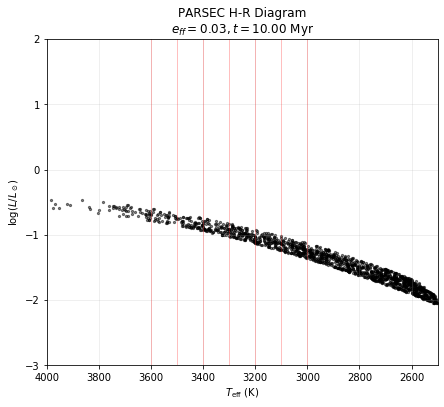

In [9]:
plt.figure(figsize=(7, 6))

# isochrone grid
cmap = plt.get_cmap('coolwarm')
for i, iso in enumerate(iso_grid):
    frac = i / max(len(iso_grid) - 1, 1)
    color = cmap(frac)

    teff = np.array(iso.points['Teff'], dtype=float)
    lum = np.array(iso.points['L'], dtype=float) / 3.846e26
    good = (teff > 0) & (lum > 0)

    # plt.plot(teff[good], np.log10(lum[good]), color=color, alpha=0.7, lw=1.0)

# stars
plt.scatter(df_hr['teff'], df_hr['logL'], s=5, alpha=0.5, color='k')

# temp bins
for t in TEMP_BIN_EDGES:
    plt.axvline(t, color='red', alpha=0.25, lw=1)

plt.xlim(2500, 4000)
plt.ylim(-3, 2)
    
plt.xlabel(r'$T_{\mathrm{eff}}$ (K)')
plt.ylabel(r'$\log(L/L_\odot)$')
plt.title(f'PARSEC H-R Diagram\n$e_{{ff}}={test_eff}, t={test_time:.2f}$ Myr')
plt.gca().invert_xaxis()
plt.grid(alpha=0.25)
plt.show()

In [10]:
def build_hr_time_series(sim_path, snapshot_times_myr, eff_label):
    rows = []

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)
            df_hr, _, _ = interpolate_snapshot_hr(cluster_table)
            metrics = compute_hr_metrics(df_hr, cluster_table)

            rows.append({
                'eff': eff_label,
                't_myr': t,
                'dt90': metrics['dt90'],
                'sigma_L': metrics['sigma_L'],
                'mu_L': metrics['mu_L'],
                'n_stars_interp': len(df_hr),
                'n_stars_raw': len(cluster_table),
            })

            print(f"e_ff={eff_label:.2f}, t={t:.2f} done")
        except Exception as e:
            print(f"e_ff={eff_label:.2f}, t={t:.2f} failed: {e}")

    return pd.DataFrame(rows)

In [11]:
all_dfs = []

for eff in EFF_VALUES:
    t_star = T_STAR_BY_EFF[eff]

    # sample beyond the formation time so dt90 can plateau
    if eff == 0.01:
        times = np.arange(0.5, 22.1, 0.5)
    elif eff == 0.03:
        times = np.arange(0.5, 8.1, 0.25)
    elif eff == 0.10:
        times = np.arange(0.25, 3.1, 0.1)
    elif eff == 0.30:
        times = np.arange(0.10, 1.3, 0.05)
    elif eff == 1.00:
        times = np.arange(0.05, 0.6, 0.02)

    df_eff = build_hr_time_series(SIM_PATHS[eff], times, eff)
    all_dfs.append(df_eff)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.head()

e_ff=0.01, t=0.50 done
e_ff=0.01, t=1.00 done
e_ff=0.01, t=1.50 done
e_ff=0.01, t=2.00 done
e_ff=0.01, t=2.50 done
e_ff=0.01, t=3.00 done
e_ff=0.01, t=3.50 done
e_ff=0.01, t=4.00 done
e_ff=0.01, t=4.50 done
e_ff=0.01, t=5.00 done
e_ff=0.01, t=5.50 done
e_ff=0.01, t=6.00 done
e_ff=0.01, t=6.50 done
e_ff=0.01, t=7.00 done
e_ff=0.01, t=7.50 done
e_ff=0.01, t=8.00 done
e_ff=0.01, t=8.50 done
e_ff=0.01, t=9.00 done
e_ff=0.01, t=9.50 done
e_ff=0.01, t=10.00 done
e_ff=0.01, t=10.50 done
e_ff=0.01, t=11.00 done
e_ff=0.01, t=11.50 done
e_ff=0.01, t=12.00 done
e_ff=0.01, t=12.50 done
e_ff=0.01, t=13.00 done
e_ff=0.01, t=13.50 done
e_ff=0.01, t=14.00 done
e_ff=0.01, t=14.50 done
e_ff=0.01, t=15.00 done
e_ff=0.01, t=15.50 done
e_ff=0.01, t=16.00 done
e_ff=0.01, t=16.50 done
e_ff=0.01, t=17.00 done
e_ff=0.01, t=17.50 done
e_ff=0.01, t=18.00 done
e_ff=0.01, t=18.50 done
e_ff=0.01, t=19.00 done
e_ff=0.01, t=19.50 done
e_ff=0.01, t=20.00 done
e_ff=0.01, t=20.50 done
e_ff=0.01, t=21.00 done
e_ff=0.01, 

,eff,t_myr,dt90,sigma_L,mu_L,n_stars_interp,n_stars_raw
0,0.01,0.5,0.458436,NaN,NaN,0,142
1,0.01,1.0,0.956535,NaN,NaN,0,227
2,0.01,1.5,1.323560,NaN,NaN,0,263
3,0.01,2.0,1.911879,NaN,NaN,0,306
4,0.01,2.5,2.396428,NaN,NaN,0,406


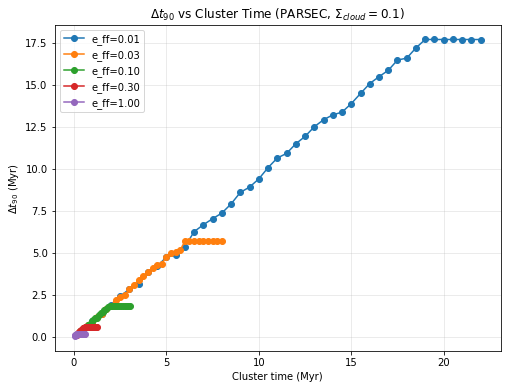

In [12]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['dt90'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel('Cluster time (Myr)')
plt.ylabel(r'$\Delta t_{90}$ (Myr)')
plt.title(r'$\Delta t_{90}$ vs Cluster Time (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

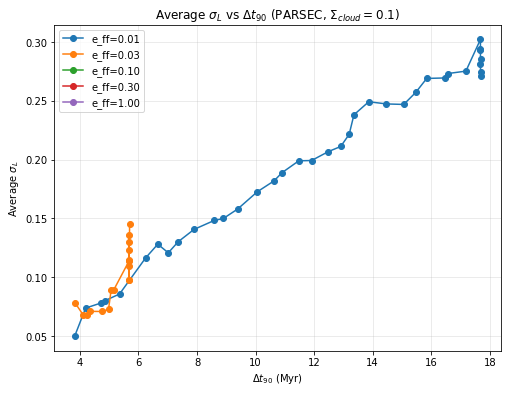

In [13]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('dt90')
    plt.plot(sub['dt90'], sub['sigma_L'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel(r'Average $\sigma_L$')
plt.title(r'Average $\sigma_L$ vs $\Delta t_{90}$ (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

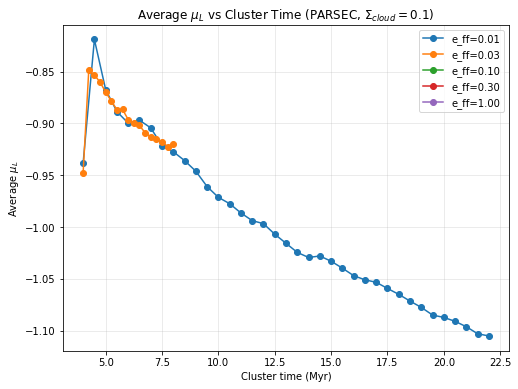

In [14]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['mu_L'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel('Cluster time (Myr)')
plt.ylabel(r'Average $\mu_L$')
plt.title(r'Average $\mu_L$ vs Cluster Time (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [16]:
summary = (
    df_all.groupby('eff')[['dt90', 'sigma_L', 'mu_L', 'n_stars_interp', 'n_stars_raw']]
    .agg(['min', 'max', 'mean'])
)

summary

dt90                         sigma_L                          mu_L  \
           min        max       mean       min       max      mean       min   
eff                                                                            
0.01  0.458436  17.686496  10.311317  0.049972  0.302151  0.199106 -1.105216   
0.03  0.449319   5.699137   3.724613  0.067855  0.145352  0.098462 -0.947633   
0.10  0.209298   1.810275   1.324450       NaN       NaN       NaN       NaN   
0.30  0.082383   0.583875   0.467465       NaN       NaN       NaN       NaN   
1.00  0.039948   0.175667   0.158463       NaN       NaN       NaN       NaN   

                         n_stars_interp                   n_stars_raw        \
           max      mean            min   max        mean         min   max   
eff                                                                           
0.01 -0.818893 -1.000052              0  1895  827.568182         142  2766   
0.03 -0.848746 -0.895649              0  1270  358.225806         367  2503   
0.10       NaN       NaN              0     0    0.000000         489  2482   
0.30       NaN       NaN              0     0    0.000000         545  2466   
1.00       NaN       NaN              0     0    0.000000         718  2678   

                   
             mean  
eff                
0.01  1606.340909  
0.03  1687.935484  
0.10  1850.689655  
0.30  1967.041667  
1.00  2392.571429